<a href="https://colab.research.google.com/github/JennyonOort/2024-09-04-git/blob/main/NIH_Chets_Xray.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install kaggle
!pip install kagglehub
# ✅ Reinstall the right PyTorch & TorchVision
!pip install torch==2.0.1 torchvision==0.15.2
# ✅ Install TPU support (torch_xla)



In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Step 2: Set paths
import os
import pandas as pd
import zipfile

base_path = '/content/drive/MyDrive/nih_xray'
zip_path = os.path.join(base_path, 'images_001.zip')
csv_path = os.path.join(base_path, 'Data_Entry_2017.csv')



extract_dir = '/content/drive/MyDrive/nih_xray/images/images_001'

# Make sure the target directory exists
os.makedirs(extract_dir, exist_ok=True)

# Unzip
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

print("✅ Unzipped successfully to:", extract_dir)



✅ Unzipped successfully to: /content/drive/MyDrive/nih_xray/images/images_001


In [ ]:
#Creating dataframe of data

import pandas as pd
import os

csv_path = '/content/drive/MyDrive/nih_xray/Data_Entry_2017.csv'
image_dir = '/content/drive/MyDrive/nih_xray/images/images_001/images_001/images'

# Load CSV
df = pd.read_csv(csv_path)
# Only keep images that exist in the unzipped folder
existing_images = set(os.listdir(image_dir))
df = df[df['Image Index'].isin(existing_images)]

# Create image_path column
df['image_path'] = df['Image Index'].apply(lambda x: os.path.join(image_dir, x))

# Preview
df[['Image Index', 'image_path']].head()

<ipython-input-54-3a37471068b9>:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['image_path'] = df['Image Index'].apply(lambda x: os.path.join(image_dir, x))


,Image Index,image_path
0,00000001_000.png,/content/drive/MyDrive/nih_xray/images/images_...
1,00000001_001.png,/content/drive/MyDrive/nih_xray/images/images_...
2,00000001_002.png,/content/drive/MyDrive/nih_xray/images/images_...
3,00000002_000.png,/content/drive/MyDrive/nih_xray/images/images_...
4,00000003_000.png,/content/drive/MyDrive/nih_xray/images/images_...


In [ ]:
# Creating output labels

from itertools import chain

# Get all unique labels
all_labels = sorted(set(chain.from_iterable(df['Finding Labels'].str.split('|'))))
print(all_labels)
# One-hot encode
for label in all_labels:
    df[label] = df['Finding Labels'].apply(lambda x: int(label in x))

['Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Effusion', 'Emphysema', 'Fibrosis', 'Hernia', 'Infiltration', 'Mass', 'No Finding', 'Nodule', 'Pleural_Thickening', 'Pneumonia', 'Pneumothorax']


In [ ]:
#check if we have any missing lables
df['Finding Labels'].isnull().sum()

0

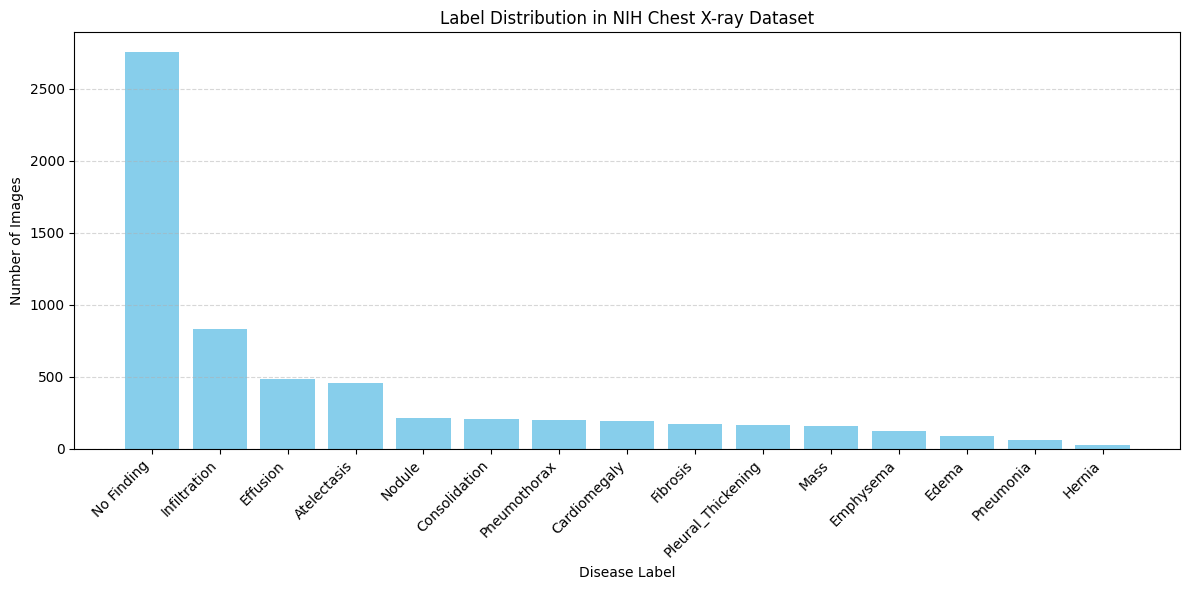

In [ ]:
# Bar graph of lablel distribution

import matplotlib.pyplot as plt
from collections import Counter

# Split the multi-label strings into lists and flatten
all_labels_flat = list(chain.from_iterable(df['Finding Labels'].dropna().str.split('|')))
label_counts = Counter(all_labels_flat)

# Sort by frequency (optional)
label_counts = dict(sorted(label_counts.items(), key=lambda x: x[1], reverse=True))


plt.figure(figsize=(12, 6))
plt.bar(label_counts.keys(), label_counts.values(), color='skyblue')
plt.xticks(rotation=45, ha='right')
plt.title('Label Distribution in NIH Chest X-ray Dataset')
plt.xlabel('Disease Label')
plt.ylabel('Number of Images')
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()


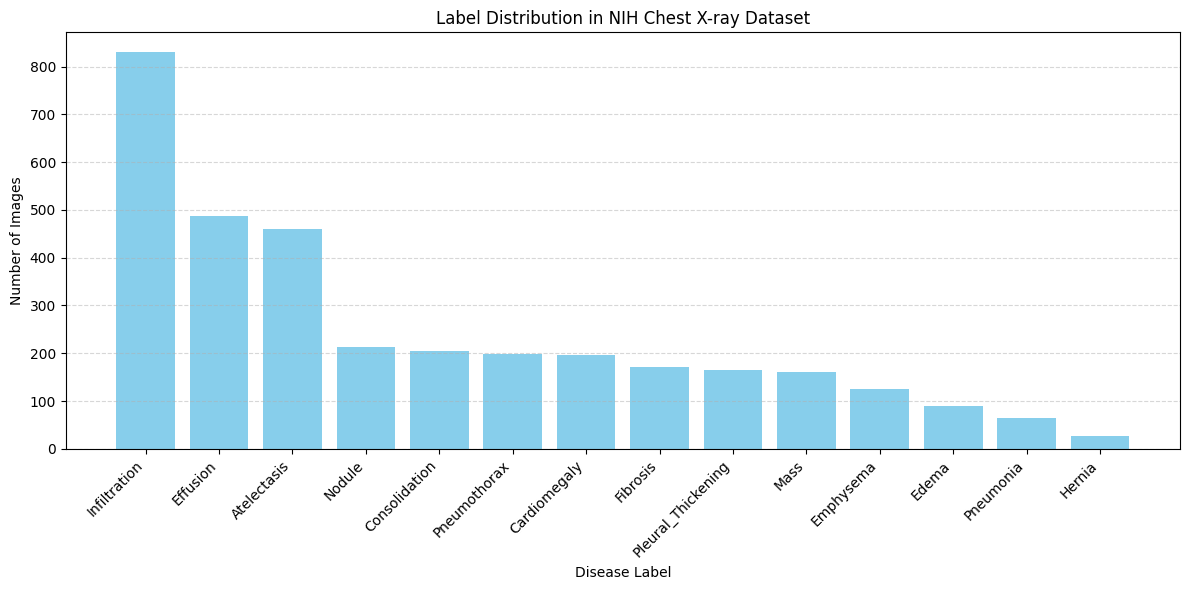

In [ ]:
# Remove no-findings
filttered_df = df[df['Finding Labels'] != 'No Finding']

# Split the multi-label strings into lists and flatten
all_labels_flat = list(chain.from_iterable(filttered_df['Finding Labels'].dropna().str.split('|')))
label_counts = Counter(all_labels_flat)

# Sort by frequency (optional)
label_counts = dict(sorted(label_counts.items(), key=lambda x: x[1], reverse=True))


plt.figure(figsize=(12, 6))
plt.bar(label_counts.keys(), label_counts.values(), color='skyblue')
plt.xticks(rotation=45, ha='right')
plt.title('Label Distribution in NIH Chest X-ray Dataset')
plt.xlabel('Disease Label')
plt.ylabel('Number of Images')
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()



<ipython-input-59-891b37163659>:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filttered_df[label] = filttered_df['Finding Labels'].apply(lambda x: int(label in x))


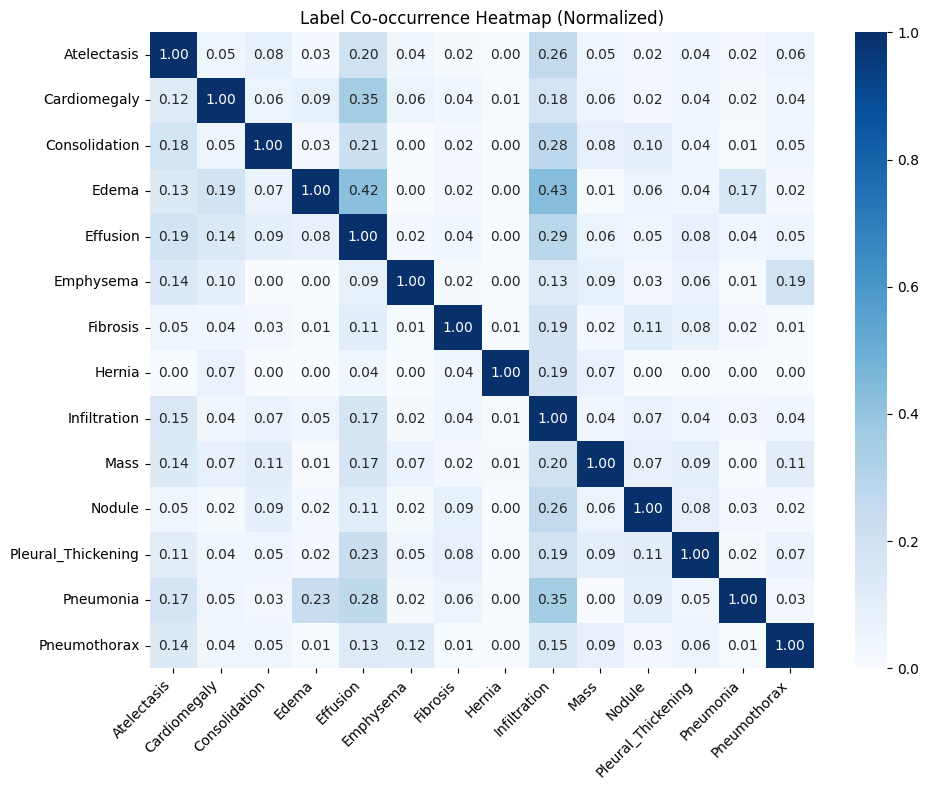

In [ ]:
# Convert labels to one-hot encoding representation
import seaborn as sns
all_labels = sorted(set(chain.from_iterable(filttered_df['Finding Labels'].str.split('|'))))

for label in all_labels:
    filttered_df[label] = filttered_df['Finding Labels'].apply(lambda x: int(label in x))



# correlation of binary label columns
label_df = filttered_df[all_labels]  # df with one column per label (0/1)
correlation_matrix = label_df.T.dot(label_df)  # Dot product counts co-occurrence

# Optional: normalize by diagonal to get % co-occurrence
import numpy as np
normalized_matrix = correlation_matrix.div(np.diag(correlation_matrix), axis=0)

# Plot settings
plt.figure(figsize=(10, 8))
sns.heatmap(normalized_matrix, cmap='Blues', annot=True, fmt=".2f", xticklabels=True, yticklabels=True)
plt.title("Label Co-occurrence Heatmap (Normalized)")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

<ipython-input-60-549246bbc6a9>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filttered_df['Patient Gender'] = filttered_df['Patient Gender'].str.upper().map({'M': 'Male', 'F': 'Female'})


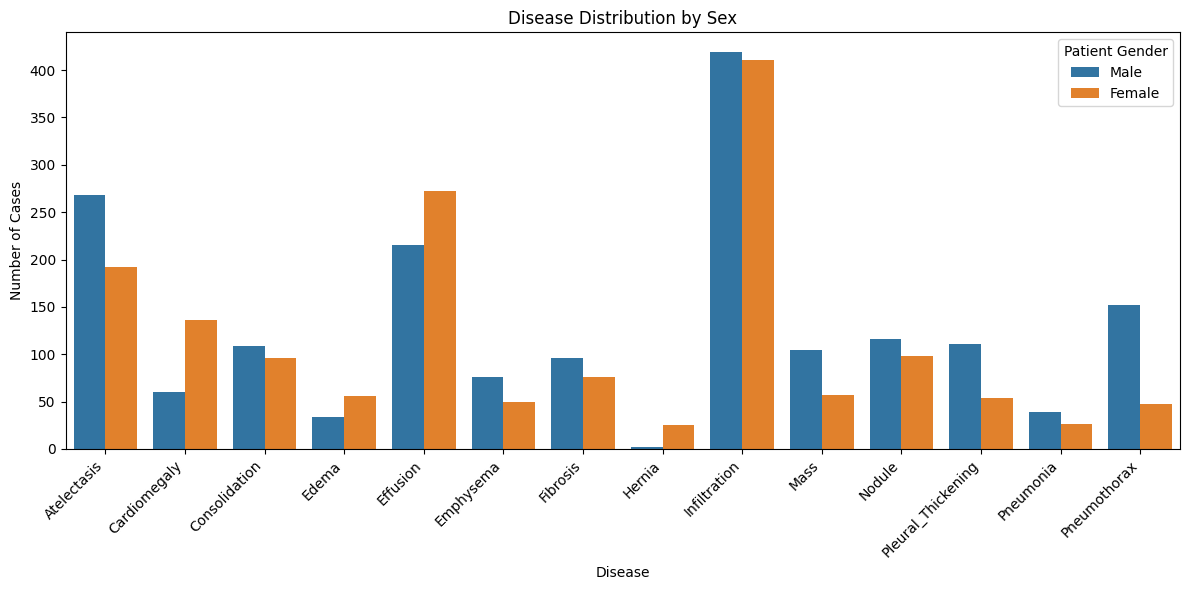

In [ ]:
# Bar graph of Patient Gender vs Disease relation


#clean gender column (some datasets use M/F, others Male/Female)
filttered_df['Patient Gender'] = filttered_df['Patient Gender'].str.upper().map({'M': 'Male', 'F': 'Female'})

# Melt the DataFrame to long format for plotting
sex_melted = filttered_df.melt(id_vars=['Patient Gender'], value_vars=all_labels,
                     var_name='Disease', value_name='Presence')

# Filter only positive labels
sex_melted = sex_melted[sex_melted['Presence'] == 1]

# Plot
plt.figure(figsize=(12, 6))
sns.countplot(data=sex_melted, x='Disease', hue='Patient Gender')
plt.title("Disease Distribution by Sex")
plt.xticks(rotation=45, ha='right')
plt.ylabel("Number of Cases")
plt.tight_layout()
plt.show()

<ipython-input-61-785dd856587f>:10: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(data=age_melted, x='Disease', y='Patient Age', inner='quartile', scale='width')


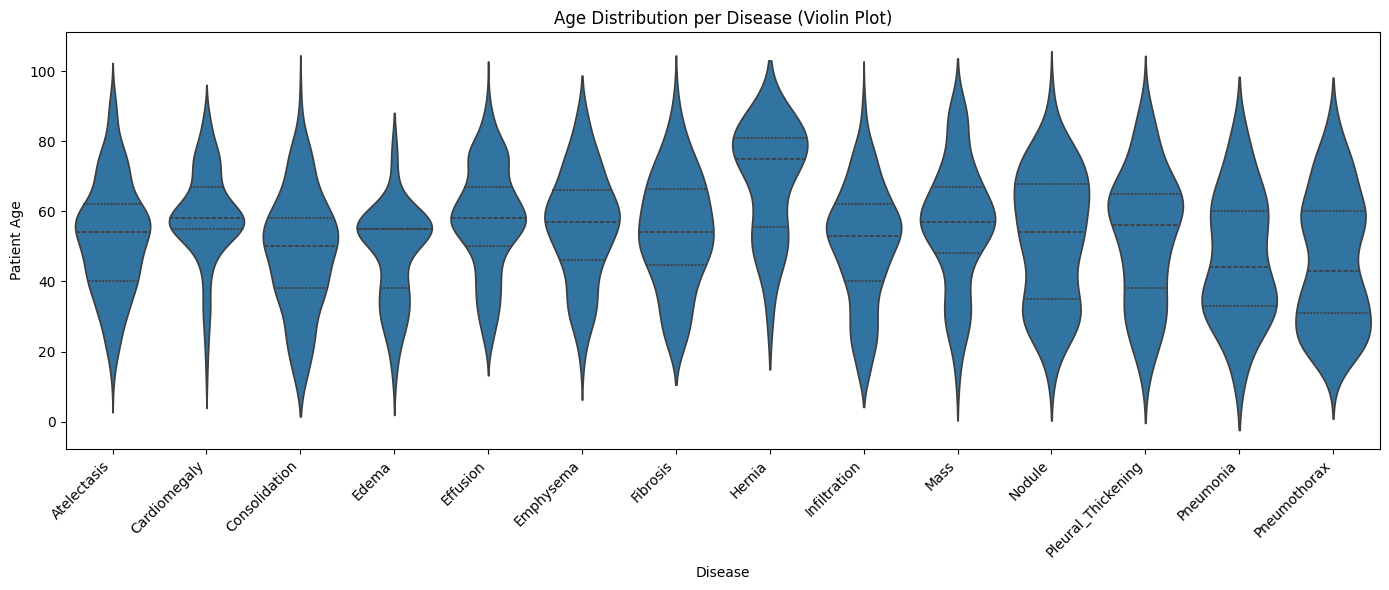

In [ ]:
# Violin plot of patient age ditsribution and diseases
age_melted = filttered_df.melt(id_vars=['Patient Age'], value_vars=all_labels,
                     var_name='Disease', value_name='Presence')

# Filter positive cases only
age_melted = age_melted[age_melted['Presence'] == 1]

# Plot
plt.figure(figsize=(14, 6))
sns.violinplot(data=age_melted, x='Disease', y='Patient Age', inner='quartile', scale='width')
plt.title("Age Distribution per Disease (Violin Plot)")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
# Check for missing Values

# Count missing (NaN) values in each column
missing_counts = filttered_df.isnull().sum()
print(missing_counts)
# Show only columns with at least one missing value
missing_counts = missing_counts[missing_counts > 0]

# Sort by number of missing values
missing_counts = missing_counts.sort_values(ascending=False)

# Display
print("🔎 Missing values per column:")




Image Index                       0
Finding Labels                    0
Follow-up #                       0
Patient ID                        0
Patient Age                       0
Patient Gender                    0
View Position                     0
OriginalImage[Width               0
Height]                           0
OriginalImagePixelSpacing[x       0
y]                                0
Unnamed: 11                    2245
image_path                        0
Atelectasis                       0
Cardiomegaly                      0
Consolidation                     0
Edema                             0
Effusion                          0
Emphysema                         0
Fibrosis                          0
Hernia                            0
Infiltration                      0
Mass                              0
No Finding                        0
Nodule                            0
Pleural_Thickening                0
Pneumonia                         0
Pneumothorax                

In [ ]:
# Columns to keep: labels + age + gender + image path
columns_to_keep = all_labels + ['Patient Age', 'Patient Gender', 'image_path']

# Keep only those columns
filttered_df = filttered_df[columns_to_keep]
filttered_df

,Atelectasis,Cardiomegaly,Consolidation,Edema,Effusion,Emphysema,Fibrosis,Hernia,Infiltration,Mass,Nodule,Pleural_Thickening,Pneumonia,Pneumothorax,Patient Age,Patient Gender,image_path
0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,58,Male,/content/drive/MyDrive/nih_xray/images/images_...
1,0,1,0,0,0,1,0,0,0,0,0,0,0,0,58,Male,/content/drive/MyDrive/nih_xray/images/images_...
2,0,1,0,0,1,0,0,0,0,0,0,0,0,0,58,Male,/content/drive/MyDrive/nih_xray/images/images_...
4,0,0,0,0,0,0,0,1,0,0,0,0,0,0,81,Female,/content/drive/MyDrive/nih_xray/images/images_...
5,0,0,0,0,0,0,0,1,0,0,0,0,0,0,74,Female,/content/drive/MyDrive/nih_xray/images/images_...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4981,1,0,0,0,0,0,0,0,0,0,0,0,0,1,81,Male,/content/drive/MyDrive/nih_xray/images/images_...
4982,0,0,1,0,0,0,0,0,0,0,1,0,0,0,14,Male,/content/drive/MyDrive/nih_xray/images/images_...
4984,0,0,1,0,0,0,0,0,1,0,0,0,0,0,17,Male,/content/drive/MyDrive/nih_xray/images/images_...
4986,0,0,0,0,0,0,0,0,0,0,1,0,0,0,48,Male,/content/drive/MyDrive/nih_xray/images/images_...


In [ ]:
# Check missing counts
missing_meta = filttered_df[['Patient Age', 'Patient Gender']].isnull().sum()

# Also show % missing
missing_meta_percent = (filttered_df[['Patient Age', 'Patient Gender']].isnull().mean() * 100).round(2)

# Combine into a nice table
missing_summary = pd.DataFrame({
    'Missing Count': missing_meta,
    'Missing %': missing_meta_percent
})

missing_summary

,Missing Count,Missing %
Patient Age,0,0.0
Patient Gender,0,0.0


In [ ]:
# Missing values of gender and age


# Check missing counts
missing_meta = filttered_df[['Patient Age', 'Patient Gender']].isnull().sum()

# Also show % missing
missing_meta_percent = (filttered_df[['Patient Age', 'Patient Gender']].isnull().mean() * 100).round(2)

# Combine into a nice table
missing_summary = pd.DataFrame({
    'Missing Count': missing_meta,
    'Missing %': missing_meta_percent
})

missing_summary

,Missing Count,Missing %
Patient Age,0,0.0
Patient Gender,0,0.0


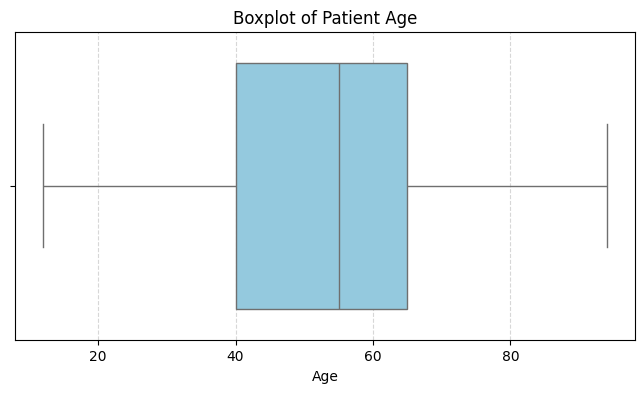

🔎 Found 0 outliers in Patient Age


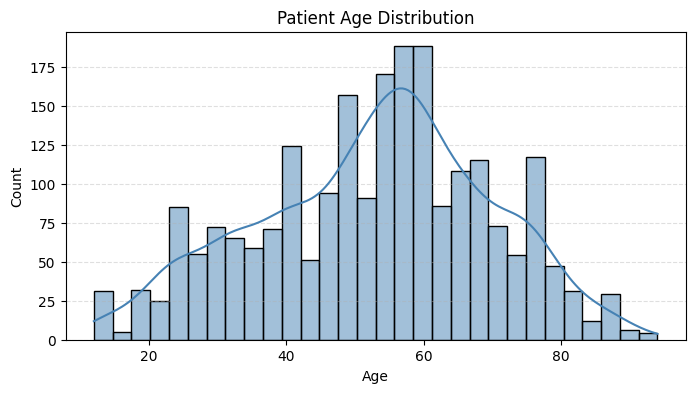

In [ ]:
#Checking for Age outliers
filttered_df['Patient Age'].describe()

plt.figure(figsize=(8, 4))
sns.boxplot(x=filttered_df['Patient Age'], color='skyblue')
plt.title("Boxplot of Patient Age")
plt.xlabel("Age")
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.show()


Q1 = filttered_df['Patient Age'].quantile(0.25)
Q3 = filttered_df['Patient Age'].quantile(0.75)
IQR = Q3 - Q1

# Define outlier range
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Find outliers
outliers = filttered_df[(filttered_df['Patient Age'] < lower_bound) | (filttered_df['Patient Age'] > upper_bound)]

print(f"🔎 Found {len(outliers)} outliers in Patient Age")
outliers[['Patient Age']].head()




plt.figure(figsize=(8, 4))
sns.histplot(filttered_df['Patient Age'], bins=30, kde=True, color='steelblue')
plt.title("Patient Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.show()

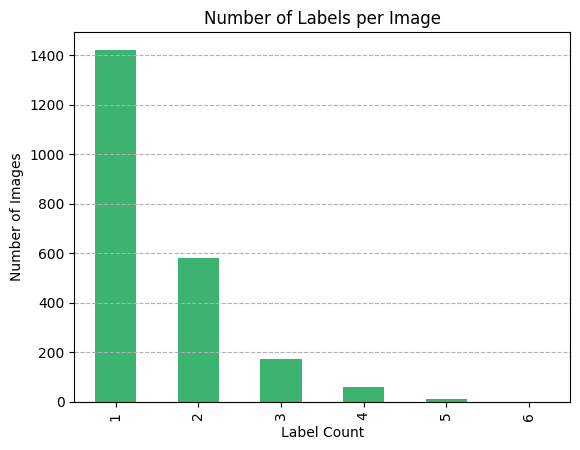

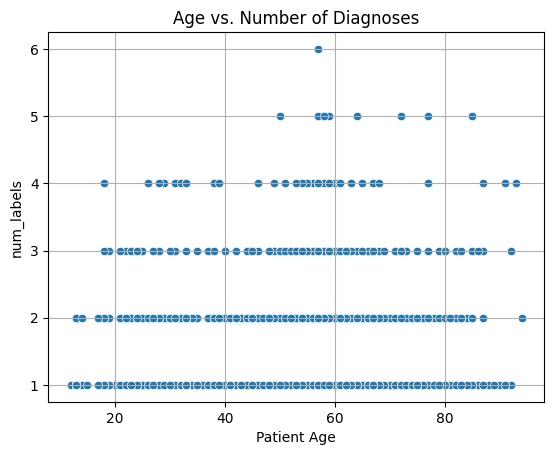

In [ ]:
# Check how many lables per patient
filttered_df['num_labels'] = filttered_df[all_labels].sum(axis=1)

filttered_df['num_labels'].value_counts().sort_index().plot(kind='bar', color='mediumseagreen')
plt.title("Number of Labels per Image")
plt.xlabel("Label Count")
plt.ylabel("Number of Images")
plt.grid(axis='y', linestyle='--')
plt.show()


filttered_df['num_labels'] = filttered_df[all_labels].sum(axis=1)
sns.scatterplot(data=filttered_df, x='Patient Age', y='num_labels')
plt.title("Age vs. Number of Diagnoses")
plt.grid(True)
plt.show()


**Data Preproccesing + Data Augmentation **

In [ ]:
label_counts = filttered_df[all_labels].sum().sort_values()
print("🔍 Least frequent labels:")
print(label_counts.head())


Missing paths: 0


,Image Index,image_path
0,00000001_000.png,/root/.cache/kagglehub/datasets/nih-chest-xray...
1,00000001_001.png,/root/.cache/kagglehub/datasets/nih-chest-xray...
2,00000001_002.png,/root/.cache/kagglehub/datasets/nih-chest-xray...
3,00000002_000.png,/root/.cache/kagglehub/datasets/nih-chest-xray...
4,00000003_000.png,/root/.cache/kagglehub/datasets/nih-chest-xray...


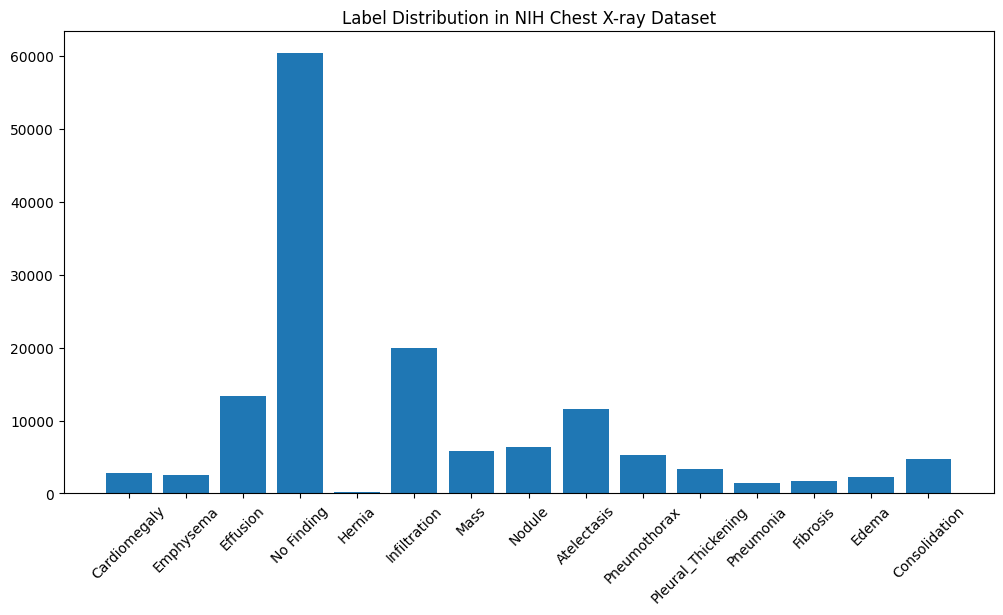

In [ ]:
import matplotlib.pyplot as plt
from collections import Counter
from itertools import chain

# Split pipe-separated labels
label_lists = df['Finding Labels'].str.split('|')
label_counts = Counter(chain.from_iterable(label_lists))

# Plot top 14 labels
plt.figure(figsize=(12, 6))
plt.bar(label_counts.keys(), label_counts.values())
plt.xticks(rotation=45)
plt.title("Label Distribution in NIH Chest X-ray Dataset")
plt.show()


In [ ]:
print(df.columns)


Index(['Image Index', 'Finding Labels', 'Follow-up #', 'Patient ID',
       'Patient Age', 'Patient Gender', 'View Position', 'OriginalImage[Width',
       'Height]', 'OriginalImagePixelSpacing[x', 'y]', 'Unnamed: 11',
       'image_path'],
      dtype='object')


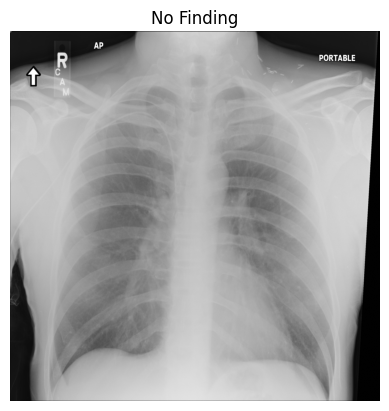

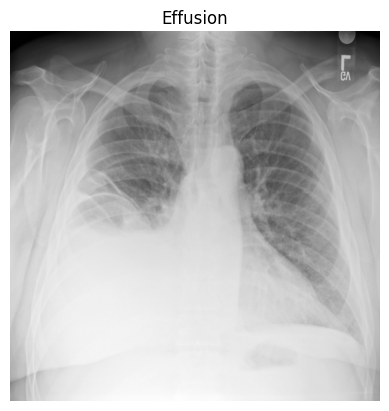

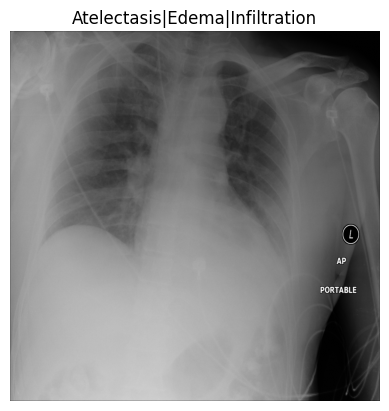

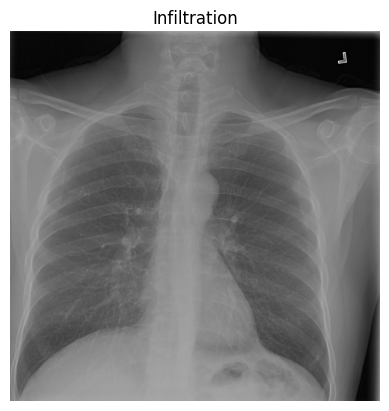

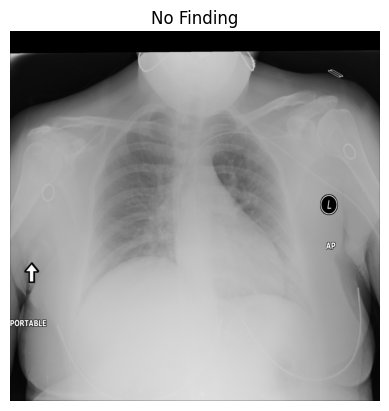

['Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Effusion', 'Emphysema', 'Fibrosis', 'Hernia', 'Infiltration', 'Mass', 'No Finding', 'Nodule', 'Pleural_Thickening', 'Pneumonia', 'Pneumothorax']


In [ ]:
df['num_labels'] = df['Finding Labels'].str.count('\|') + 1
df['multi_label'] = df['num_labels'] > 1
df['multi_label'].value_counts()


import matplotlib.image as mpimg

sample = df.sample(5)
for _, row in sample.iterrows():
    img = mpimg.imread(row['image_path'])
    plt.imshow(img, cmap='gray')
    plt.title(row['Finding Labels'])
    plt.axis('off')
    plt.show()


# All 14 disease labels
all_labels = sorted(set(chain.from_iterable(df['Finding Labels'].str.split('|'))))
print(all_labels)

for label in all_labels:
    df[label] = df['Finding Labels'].apply(lambda x: int(label in x))

In [ ]:
# All 14 disease labels
all_labels = sorted(set(chain.from_iterable(df['Finding Labels'].str.split('|'))))
print(all_labels)

for label in all_labels:
    df[label] = df['Finding Labels'].apply(lambda x: int(label in x))

['Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Effusion', 'Emphysema', 'Fibrosis', 'Hernia', 'Infiltration', 'Mass', 'No Finding', 'Nodule', 'Pleural_Thickening', 'Pneumonia', 'Pneumothorax']


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import models, transforms
from PIL import Image
import torch_xla
import torch_xla.core.xla_model as xm
import torch_xla.distributed.parallel_loader as pl

# ✅ Set the TPU device
device = xm.xla_device()

# ✅ Custom Dataset
class NIHChestXrayDataset(Dataset):
    def __init__(self, df, label_cols, transform=None):
        self.df = df
        self.label_cols = label_cols
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = Image.open(row['image_path']).convert('RGB')
        label = torch.tensor(row[self.label_cols].values.astype('float32'))

        if self.transform:
            image = self.transform(image)
        return image, label

# ✅ Image transform
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

# ✅ Create dataset and DataLoader
train_dataset = NIHChestXrayDataset(df, label_cols=all_labels, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0)

# ✅ Define model
model = models.resnet18(pretrained=True)
model.fc = nn.Linear(model.fc.in_features, len(all_labels))
model = model.to(device)

# ✅ Loss and optimizer
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

# ✅ Training loop
epochs = 5
for epoch in range(epochs):
    model.train()
    running_loss = 0.0

    # Wrap DataLoader for TPU
    para_loader = pl.MpDeviceLoader(train_loader, device)

    for images, labels in para_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        xm.optimizer_step(optimizer)

        running_loss += loss.item()

    print(f"Epoch {epoch+1} - Avg Loss: {running_loss / len(train_loader):.4f}")

ImportError: /usr/local/lib/python3.11/dist-packages/_XLAC.cpython-311-x86_64-linux-gnu.so: undefined symbol: _ZNK5torch4lazy17LazyGraphExecutor16ShouldSyncTensorERKN3c1013intrusive_ptrINS0_10LazyTensorENS2_6detail34intrusive_target_default_null_typeIS4_EEEE

In [ ]:
import torch
import torch.nn as nn
import torch_xla
import torch_xla.core.xla_model as xm

device = xm.xla_device()
x = torch.randn(5, 10).to(device)
y = torch.randn(5, 1).to(device)

model = nn.Linear(10, 1).to(device)
loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters())

for _ in range(3):
    pred = model(x)
    loss = loss_fn(pred, y)
    loss.backward()
    xm.optimizer_step(optimizer)
    print("Loss:", loss.item())

ModuleNotFoundError: No module named 'torch_xla'

In [ ]:
model.eval()
with torch.no_grad():
    outputs = model(images)
    probs = torch.sigmoid(outputs)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')